Digits MNIST Classification using CNN

Dataset - MNIST ("Modified National Institute of Standards and Technology") is the de facto “hello world” dataset of computer vision.
Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms.
As new machine learning techniques emerge, MNIST remains a reliable resource for researchers and learners alike.

Task - To correctly identify digits from a dataset of tens of thousands of handwritten images in the test dataset

In [8]:
### Install Required Libraries
# Uncomment and run the following lines if the libraries are not already installed
#!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

In [6]:
## Import Required Libraries
# Numerical operations
import numpy as np 
# Data manipulation
import pandas as pd 

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import matplotlib.image as mpimg

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Deep learning with TensorFlow/Keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [14]:
#Import Dataset
df = pd.read_csv("/Users/dishachaudhary/Downloads/Portfolio Dataset/MNIST/sample_submission.csv")
train = pd.read_csv("/Users/dishachaudhary/Downloads/Portfolio Dataset/MNIST/train.csv")
test = pd.read_csv("/Users/dishachaudhary/Downloads/Portfolio Dataset/MNIST/test.csv")

In [16]:
# Display the first few rows to confirm loading
print("Sample Submission Data:")
print(df.head())

print("\nTraining Data:")
print(train.head())

print("\nTest Data:")
print(test.head())

Sample Submission Data:
   ImageId  Label
0        1      0
1        2      0
2        3      0
3        4      0
4        5      0

Training Data:
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4    

In [18]:
### Check for Missing Values
missing_train = train.isna().sum().sum()
missing_test = test.isna().sum().sum()
print(f"Missing values in train dataset: {missing_train}")
print(f"Missing values in test dataset: {missing_test}")

Missing values in train dataset: 0
Missing values in test dataset: 0


EDA 

/var/folders/4k/hdd2ddtn2tqcvgfqh77lmjvc0000gn/T/ipykernel_7432/3959220762.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train['label'], palette='Dark2')


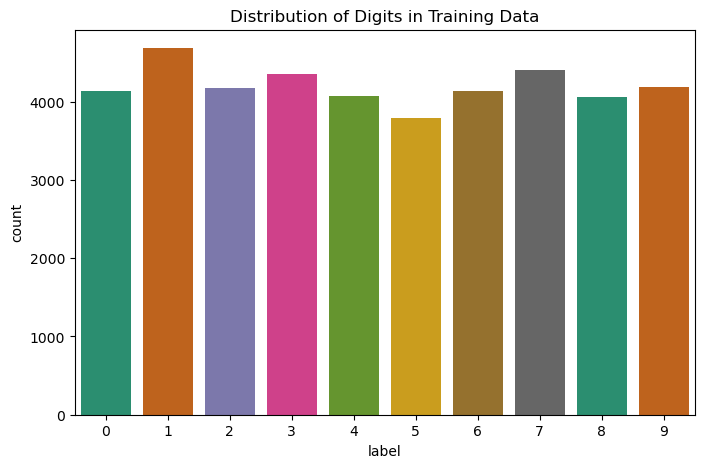

In [21]:
### Exploratory Data Analysis 
#Label Count
plt.figure(figsize=(8, 5))
sns.countplot(x=train['label'], palette='Dark2')
plt.title('Distribution of Digits in Training Data')
plt.show()

In [23]:
train['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

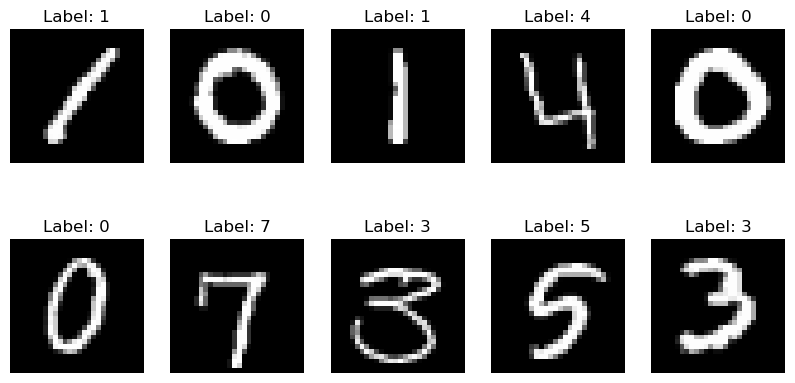

In [25]:
### Display Sample Images for training data 
fig, ax = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    img = train.iloc[i, 1:].values.reshape(28, 28)
    ax[i // 5, i % 5].imshow(img, cmap='gray')
    ax[i // 5, i % 5].set_title(f"Label: {train.iloc[i, 0]}")
    ax[i // 5, i % 5].axis('off')
plt.show()

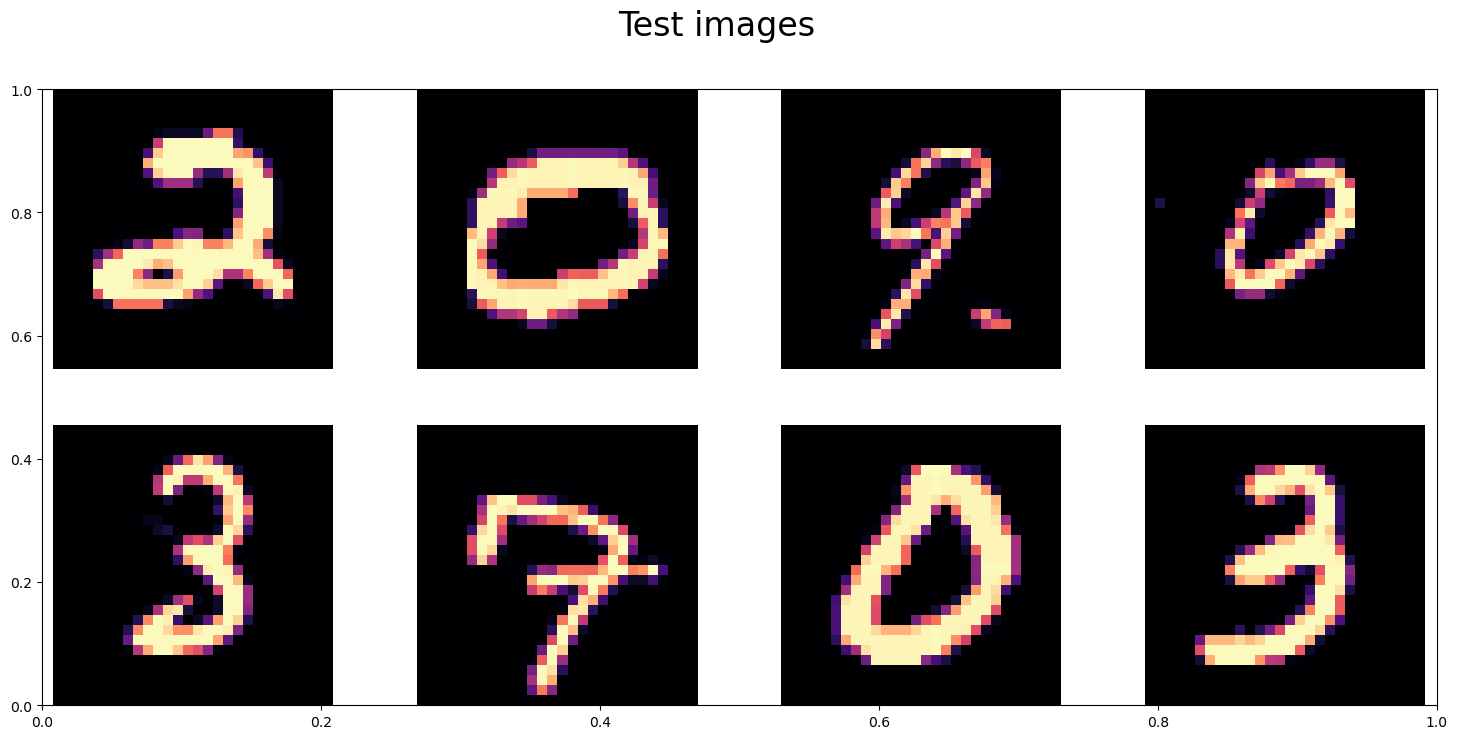

In [27]:
### Display Sample Images for test data 
fig, ax = plt.subplots(figsize=(18, 8))
for ind, row in test.iloc[:8, :].iterrows():
    plt.subplot(2, 4, ind+1)
    img = row.to_numpy()[:].reshape(28, 28)
    fig.suptitle('Test images', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='magma')

Data Preprocessing

In [30]:
### Data Preprocessing
# split into image and labels and convert to numpy array
X = train.iloc[:, 1:].to_numpy()  # Pixel values
y = train['label'].to_numpy() # Labels

# test dataset
test = test.loc[:, :].to_numpy()

for i in [X, y, test]:
    print(i.shape)

(42000, 784)
(42000,)
(28000, 784)


In [32]:
#Data Normalization
X = X / 255.0
test = test / 255.0

In [34]:
# Reshaping the dataset

# shape of training and test dataset
print(X.shape)
print(test.shape)

# reshape the dataframe to 3x3 matrix with 1 channel grey scale values
X = X.reshape(-1,28,28,1)
test = test.reshape(-1,28,28,1)

# shape of training and test dataset
print(X.shape)
print(test.shape)

(42000, 784)
(28000, 784)
(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [38]:
#Encoding
##One-Hot Encoding the target variable

# shape and values of target
print(y.shape)
print(y[0])

# convert Y_train to categorical by one-hot-encoding
y_enc = to_categorical(y, num_classes = 10)

# shape and values of target
print(y_enc.shape)
print(y_enc[0])

(42000,)
1
(42000, 10)
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [40]:
#Train-Test Split
###Split into Training and Validation Sets

# random seed
random_seed = 2

# train validation split
X_train, X_val, y_train_enc, y_val_enc = train_test_split(X, y_enc, test_size=0.3)

# shape
for i in [X_train, y_train_enc, X_val, y_val_enc]:
    print(i.shape)

(29400, 28, 28, 1)
(29400, 10)
(12600, 28, 28, 1)
(12600, 10)


[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


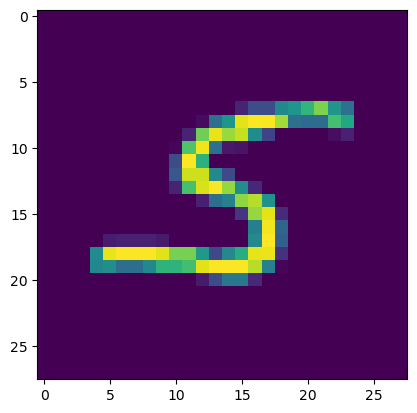

In [42]:
## Images
g = plt.imshow(X_train[0][:,:,0])
print(y_train_enc[0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


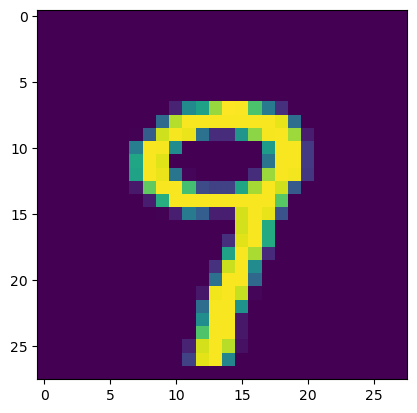

In [44]:
g = plt.imshow(X_train[9][:,:,0])
print(y_train_enc[9])

Machine Learning Algorithm - CNN
### What is a Convolutional Neural Network (CNN)?  

A **Convolutional Neural Network (CNN)** is a type of deep learning model specifically designed for processing structured grid-like data, such as images. CNNs are widely used in **computer vision** tasks like image classification, object detection, and facial recognition.  

### Key Components of a CNN:  
1. **Convolutional Layers:**  
   - Extract features (edges, textures, shapes) from the input image using filters (kernels).  
   - Mathematically, this involves performing a **convolution operation**, sliding a small filter over the image and computing weighted sums.  

2. **Activation Function (ReLU):**  
   - Introduces non-linearity to help the network learn complex patterns.  
   - Typically, the **Rectified Linear Unit (ReLU)** function is used:  
     \[
     f(x) = \max(0, x)
     \]

3. **Pooling Layers (MaxPooling/AveragePooling):**  
   - Reduce the spatial size of feature maps to make computation more efficient.  
   - Helps in **downsampling**, reducing overfitting, and improving model generalization.  

4. **Fully Connected Layers (Dense Layers):**  
   - Flatten the feature maps and pass them through traditional dense layers for classification.  
   - The final layer often uses **softmax activation** for multi-class classification.  

5. **Dropout Layers (Regularization):**  
   - Randomly deactivates neurons during training to prevent overfitting.  

### Why Use CNNs for Image Classification?  
✅ Automatically learn features from images (no need for manual feature extraction).  
✅ Capture spatial relationships in data.  
✅ Reduce computational cost using **weight sharing** in convolutions.  
✅ Outperform traditional machine learning models in image-related tasks.  

Would you like a more detailed explanation on any of these components? 🚀

In [51]:
##Define the CNN Model

#Model Parameters
INPUT_SHAPE = (28,28,1)
OUTPUT_SHAPE = 10
BATCH_SIZE = 128
EPOCHS = 10
VERBOSE = 2

In [53]:
# Model 
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=INPUT_SHAPE))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
#Compiling the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [59]:
#Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
#Model fitting
history = model.fit(X_train, y_train_enc,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    verbose=VERBOSE,
                    validation_split=0.3)

Epoch 1/10
161/161 - 7s - 43ms/step - accuracy: 0.8218 - loss: 0.5618 - val_accuracy: 0.9592 - val_loss: 0.1307
Epoch 2/10
161/161 - 6s - 36ms/step - accuracy: 0.9548 - loss: 0.1437 - val_accuracy: 0.9757 - val_loss: 0.0834
Epoch 3/10
161/161 - 5s - 33ms/step - accuracy: 0.9709 - loss: 0.0938 - val_accuracy: 0.9798 - val_loss: 0.0698
Epoch 4/10
161/161 - 5s - 32ms/step - accuracy: 0.9768 - loss: 0.0750 - val_accuracy: 0.9803 - val_loss: 0.0638
Epoch 5/10
161/161 - 5s - 33ms/step - accuracy: 0.9822 - loss: 0.0580 - val_accuracy: 0.9833 - val_loss: 0.0546
Epoch 6/10
161/161 - 5s - 32ms/step - accuracy: 0.9851 - loss: 0.0466 - val_accuracy: 0.9862 - val_loss: 0.0491
Epoch 7/10
161/161 - 5s - 33ms/step - accuracy: 0.9884 - loss: 0.0375 - val_accuracy: 0.9854 - val_loss: 0.0505
Epoch 8/10
161/161 - 6s - 35ms/step - accuracy: 0.9880 - loss: 0.0358 - val_accuracy: 0.9863 - val_loss: 0.0491
Epoch 9/10
161/161 - 5s - 33ms/step - accuracy: 0.9890 - loss: 0.0324 - val_accuracy: 0.9857 - val_loss:

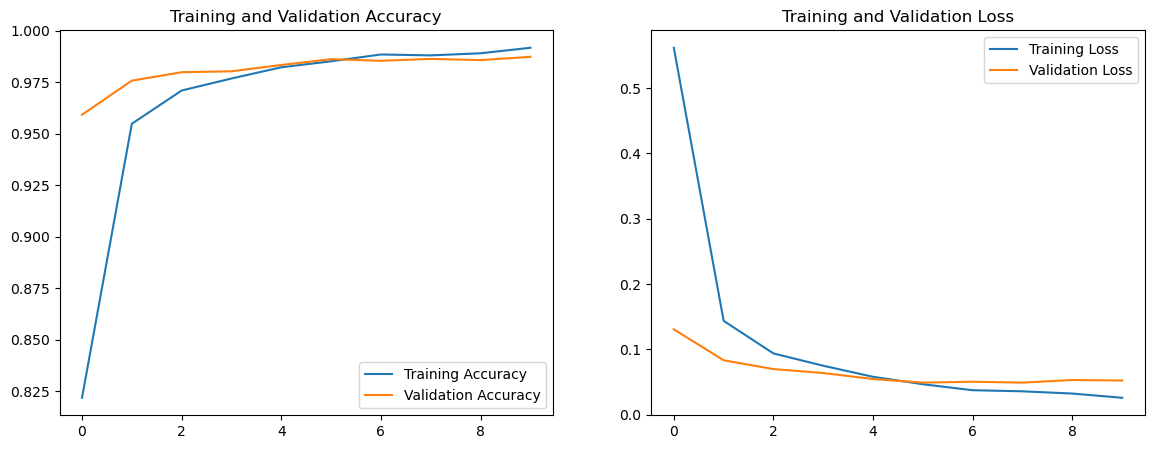

In [65]:
#Graphical Representation of Accuracy and Loss
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()

In [67]:
## Evaluating model on Validation set
# model loss and accuracy on validation set
model.evaluate(X_val, y_val_enc, verbose=False)

[0.05235406756401062, 0.9853174686431885]

In [69]:
# Make Predictions on Test Data
y_pred_enc = model.predict(X_val)

# actual
y_act = [np.argmax(i) for i in y_val_enc]

# decoding predicted values
y_pred = [np.argmax(i) for i in y_pred_enc]

print(y_pred_enc[0])
print(y_pred[0])

394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[8.3110133e-12 1.6991099e-09 7.0342909e-09 9.9999964e-01 1.0419332e-12
 3.2529104e-07 4.7412573e-12 9.4936403e-10 9.4942427e-09 4.6485402e-09]
3


In [71]:
#Classification Report
print(classification_report(y_act, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1204
           1       0.99      0.99      0.99      1418
           2       0.97      0.99      0.98      1299
           3       0.99      0.98      0.98      1291
           4       0.99      0.99      0.99      1210
           5       0.98      0.99      0.98      1164
           6       0.99      0.99      0.99      1240
           7       0.98      0.98      0.98      1303
           8       0.98      0.98      0.98      1214
           9       0.99      0.98      0.98      1257

    accuracy                           0.99     12600
   macro avg       0.99      0.99      0.99     12600
weighted avg       0.99      0.99      0.99     12600



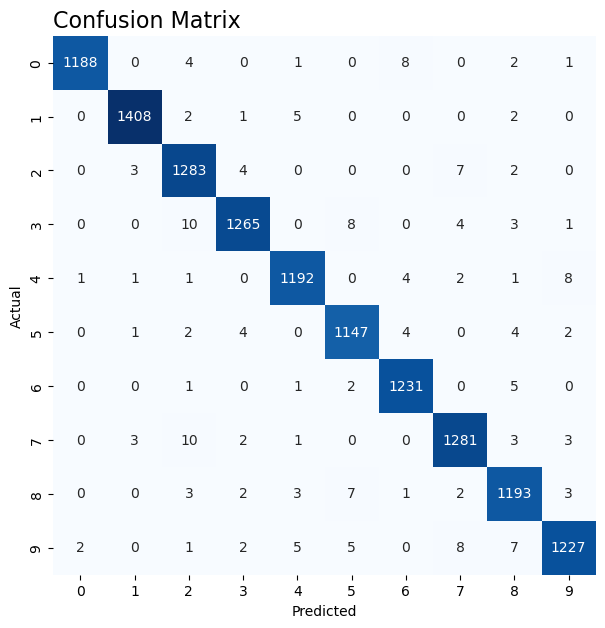

In [73]:
## Visualize Some Predictions
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(confusion_matrix(y_act, y_pred), annot=True, 
            cbar=False, fmt='1d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix', loc='left', fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

In [75]:
# predicted values
y_pred_enc = model.predict(test)

# decoding predicted values
y_pred = [np.argmax(i) for i in y_pred_enc]

print(y_pred_enc[0])
print(y_pred[0])

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[5.9985475e-11 1.8995814e-12 1.0000000e+00 4.8395202e-13 5.6619429e-14
 9.8091163e-18 4.5427912e-16 4.6817780e-12 4.0617453e-12 1.4014791e-15]
2


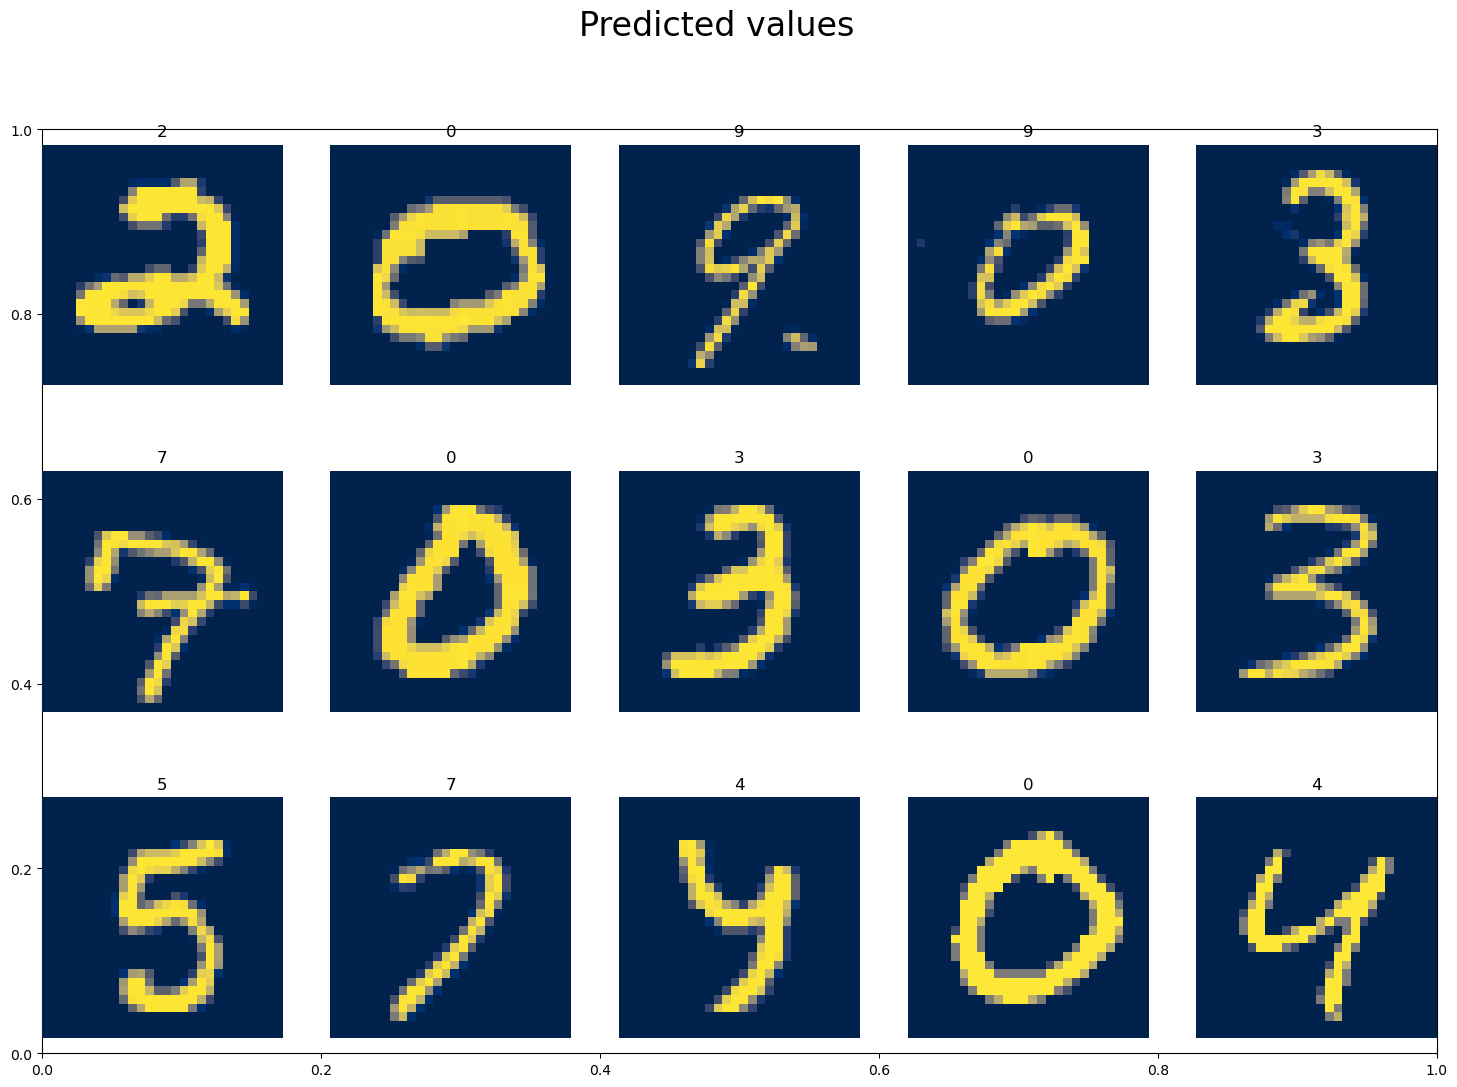

In [77]:
# predicted targets of each images
# (labels above the images are predicted labels)
fig, ax = plt.subplots(figsize=(18, 12))
for ind, row in enumerate(test[:15]):
    plt.subplot(3, 5, ind+1)
    plt.title(y_pred[ind])
    img = row.reshape(28, 28)
    fig.suptitle('Predicted values', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='cividis')